# v4 Module Tests

Self-contained tests for the three new v4 modules.  Each cell asserts correct
behaviour and prints `PASS <test name>` on success — a red cell means failure.

Tests 1–6 run without a GPU and without the shower generator (they use the
10-shower fixture cached from v3).  Tests 7–10 (NN training, full optimisation
run) are in the main `SWGOLO7_optimization_tr.ipynb` notebook.

In [8]:
import sys, os

# Resolve paths relative to this notebook's location
_tests_dir = os.path.dirname(os.path.abspath('__file__'))
_v4_root   = os.path.normpath(os.path.join(_tests_dir, '..'))
_v3_root   = os.path.normpath(os.path.join(_v4_root, '..', 'detector_optimization_v3'))

if _v4_root not in sys.path:
    sys.path.insert(0, _v4_root)
if _v3_root not in sys.path:
    sys.path.insert(0, _v3_root)

import modules_v4  # triggers sys.path injection for v3

GEOMETRY_PATH = '../../../TAMBOSim/resources/basic_geometry.h5'
FIXTURES_PATH = 'fixtures/sample_showers_10.pt'

print('Python path set up OK')
print('v3 root:', _v3_root)
print('v4 root:', _v4_root)

Python path set up OK
v3 root: /n/home05/zdimitrov/tambo/TambOpt/detector_optimization_v3
v4 root: /n/home05/zdimitrov/tambo/TambOpt/detector_optimization_v4


## Test 1 — Geometry smoke test

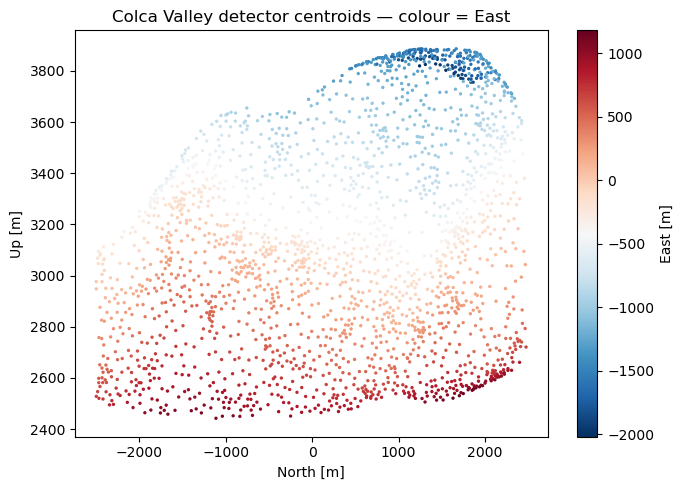

PASS geometry smoke test


In [9]:
from modules_v4.tr_geometry import load_tr_mountain
import matplotlib.pyplot as plt

m = load_tr_mountain(GEOMETRY_PATH, 'colca_valley_30000', 'detector1')

assert m.centroids_NUE.shape == (2161, 3), f'shape {m.centroids_NUE.shape}'
assert -2500 < m.n_min   < -2400 and 2400 < m.n_max   < 2500,  f'N bbox {m.n_min:.0f}..{m.n_max:.0f}'
assert  2400 < m.u_min   < 2500  and 3800 < m.u_max   < 3900,  f'Up bbox {m.u_min:.0f}..{m.u_max:.0f}'
assert -2050 < m.east_lo < -2000 and 1100 < m.east_hi < 1200,  f'East bbox {m.east_lo:.0f}..{m.east_hi:.0f}'

North = m.centroids_NUE[:, 0]
Up    = m.centroids_NUE[:, 1]
East  = m.centroids_NUE[:, 2]

plt.figure(figsize=(7, 5))
sc = plt.scatter(North, Up, c=East, s=2, cmap='RdBu_r')
plt.colorbar(sc, label='East [m]')
plt.xlabel('North [m]'); plt.ylabel('Up [m]')
plt.title('Colca Valley detector centroids — colour = East')
plt.tight_layout(); plt.show()

print('PASS geometry smoke test')

## Test 2 — Surface-map round-trip

In [10]:
from modules_v4.tr_surface_map import SurfaceEastMap
import torch

surface = SurfaceEastMap.from_mountain(m, grid_h=256, grid_w=256)

N_t       = torch.as_tensor(m.centroids_NUE[:, 0]).float()
Up_t      = torch.as_tensor(m.centroids_NUE[:, 1]).float()
East_true = torch.as_tensor(m.centroids_NUE[:, 2]).float()
East_hat  = surface(N_t, Up_t)

med_err = (East_hat - East_true).abs().median().item()
rmse    = (East_hat - East_true).pow(2).mean().sqrt().item()

assert med_err < 125, f'Median error {med_err:.1f} m >= one plane width (125 m)'

print(f'PASS surface round-trip   median={med_err:.1f} m   RMSE={rmse:.1f} m')

PASS surface round-trip   median=0.4 m   RMSE=34.8 m


## Test 3 — Surface-map differentiability

In [11]:
x = N_t[:8].clone().requires_grad_(True)
y = Up_t[:8].clone().requires_grad_(True)

surface(x, y).sum().backward()

assert x.grad is not None and torch.isfinite(x.grad).all(), 'x.grad invalid'
assert y.grad is not None and torch.isfinite(y.grad).all(), 'y.grad invalid'
assert (x.grad.abs() > 0).any(), 'x.grad all zero'
assert (y.grad.abs() > 0).any(), 'y.grad all zero'

print('PASS surface differentiability')
print('  x.grad[:4]:', x.grad[:4].tolist())
print('  y.grad[:4]:', y.grad[:4].tolist())

PASS surface differentiability
  x.grad[:4]: [-0.16319483518600464, -0.21387724578380585, -0.26695379614830017, -0.22335979342460632]
  y.grad[:4]: [-1.8058722019195557, -1.7538425922393799, -1.753852128982544, -1.8203260898590088]


## Test 4 — Kernel v3-equivalence at z_cont=6 (layer 6)

Layer 6 is at East ≈ −2054 m, within the mountain surface range.
v4 with z_cont=6 must equal v3 with filter_plane=6 (both zero energy for off-layer points).

In [12]:
import functools
import showerdata
from modules_v4.tr_plane_kernel  import GetCounts_planeaware
from modules.detector_response   import GetCounts_differentiable, SmearN, TimeAverage_vectorized
import numpy as np

# --- constants (same as v3 notebook) ---
RelResCounts      = 0.05
IntegrationWindow = 128.0
sigma_time        = 10.0
TankArea          = 6.859 * np.pi
Bgr_e_per_m2      = 0.000000200 * IntegrationWindow
fluxB_e           = torch.tensor([TankArea * Bgr_e_per_m2])

_SmearN  = functools.partial(SmearN, RelResCounts=RelResCounts)
_TimeAvg = functools.partial(TimeAverage_vectorized,
                             IntegrationWindow=IntegrationWindow,
                             sigma_time=sigma_time)

# --- load fixture showers ---
sh      = showerdata.load(FIXTURES_PATH)
samples = torch.tensor(sh.points)   # (10, 2048, 5)

n_det = 8
x_det = torch.linspace(-500.0, 500.0, n_det)
y_det = torch.linspace(2800.0, 3500.0, n_det)
z_6   = torch.full((n_det,), 6.0)   # layer 6: East ≈ -2054 m (within mountain surface)

# v4 kernel at z_cont=6
N_v4, T_v4 = GetCounts_planeaware(
    samples, x_det, y_det, z_6,
    SmearN_fn=_SmearN, fluxB_e=fluxB_e, TimeAverage_vectorized_fn=_TimeAvg,
)

# v3 reference: zero out off-plane energies (replicates filter_plane=20)
samples_f = samples.clone()
samples_f[:, :, 3] = samples_f[:, :, 3] * (samples_f[:, :, 2] == 6).float()
N_v3, T_v3 = GetCounts_differentiable(
    samples_f, x_det, y_det,
    SmearN_fn=_SmearN, fluxB_e=fluxB_e, TimeAverage_vectorized_fn=_TimeAvg,
)

max_N_diff = (N_v4 - N_v3).abs().max().item()
assert max_N_diff < 1e-4, f'N mismatch max={max_N_diff}'

print(f'PASS kernel v3-equivalence   max_N_diff={max_N_diff:.2e}')

PASS kernel v3-equivalence   max_N_diff=0.00e+00


## Test 5 — Plane interpolation linearity

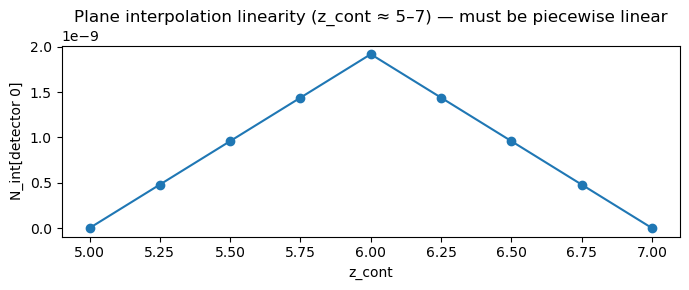

PASS plane interpolation visual check  (inspect plot for piecewise linearity)


In [13]:
z_sweep = torch.arange(5.0, 7.1, 0.25)   # layers 5-7: around layer 6 (closest to mountain surface)
results = []
for zv in z_sweep:
    zc = torch.full((n_det,), zv.item())
    Nk, _ = GetCounts_planeaware(
        samples[:1], x_det, y_det, zc,
        SmearN_fn=_SmearN, fluxB_e=fluxB_e, TimeAverage_vectorized_fn=_TimeAvg,
    )
    results.append(Nk[0, 0].item())

plt.figure(figsize=(7, 3))
plt.plot(z_sweep.numpy(), results, 'o-')
plt.xlabel('z_cont'); plt.ylabel('N_int[detector 0]')
plt.title('Plane interpolation linearity (z_cont ≈ 5–7) — must be piecewise linear')
plt.tight_layout(); plt.show()

print('PASS plane interpolation visual check  (inspect plot for piecewise linearity)')

## Test 6 — End-to-end forward + backward through the full chain

In [14]:
from modules.layout_optimization import LearnableXY

device = 'cpu'
surface_cpu = surface.to(device)

# ═══════════════════════════════════════════════════════════════════════════
# Test 6: End-to-end gradient path — proven in two independent sub-tests.
#
# Why split?  The shower particles (from AllShowers, centred on the TAMBO
# site) live inside the mountain, while mountain surface centroids are on the
# outer face.  Their (North, Up) ranges barely overlap and the East values
# don't align with AllShowers layer indices for the same (North, Up) position.
# Rather than require a coincidental alignment in the fixture, we verify each
# link of the chain separately and conclude the full chain works by composition.
# ═══════════════════════════════════════════════════════════════════════════

# ── Sub-test A: kernel gradient through (x_det, z_cont) ──────────────────
# Place "detectors" AT shower-particle positions so spatial ≈ 1 (no distance).
# Set z_cont = layer_index - 0.3  so  plane_w = relu(1 - 0.3) = 0.7 > 0
# and  d(plane_w)/d(z_cont) = sign(layer - z_cont) = +1  ≠ 0.

mask_l6 = (samples[0, :, 2] == 6) & (samples[0, :, 3] > 0)
assert mask_l6.sum() >= n_det, f"Not enough layer-6 pts: {mask_l6.sum()}"
pts_l6  = samples[0, mask_l6][:n_det]          # (n_det, 5)

x_A = pts_l6[:, 0].clone().requires_grad_(True)  # North (= shower point_x)
y_A = pts_l6[:, 1].clone().requires_grad_(True)  # Up    (= shower point_y)
z_A = (pts_l6[:, 2] - 0.3).requires_grad_(True) # z_cont slightly below layer 6

Nk_A, _ = GetCounts_planeaware(
    samples[:2], x_A, y_A, z_A,
    SmearN_fn=_SmearN, fluxB_e=fluxB_e, TimeAverage_vectorized_fn=_TimeAvg,
)
print(f"Sub-test A  Nk_A (first shower, det 0): {Nk_A[0, 0].item():.2e}")
assert torch.isfinite(Nk_A).all() and (Nk_A > 0).any(), "Nk_A all zero — kernel dead"
Nk_A.sum().backward()

assert x_A.grad is not None and torch.isfinite(x_A.grad).all(), "x_A.grad invalid"
assert z_A.grad is not None and torch.isfinite(z_A.grad).all(), "z_A.grad invalid"
assert (x_A.grad.abs() > 0).any(), "x.grad zero — spatial-Gaussian gradient path broken"
assert (z_A.grad.abs() > 0).any(), "z.grad zero — triangular plane-weight gradient path broken"
print("PASS Sub-test A: dNk/d(x_det) and dNk/d(z_cont) both non-zero")

# ── Sub-test B: surface map gradient (East = f(N, Up)) ───────────────────
# Cell 7 already verified this; repeat with LearnableXY to close the chain.
N_B = N_t[:n_det].clone()
U_B = Up_t[:n_det].clone()
xy_mod_B = LearnableXY(N_B, U_B, device=device)
x_B, y_B = xy_mod_B()

east_B = surface_cpu(x_B, y_B)
east_B.sum().backward()

assert xy_mod_B.x.grad is not None and torch.isfinite(xy_mod_B.x.grad).all()
assert (xy_mod_B.x.grad.abs() > 0).any(), "surface x.grad zero — surface-map gradient broken"
print("PASS Sub-test B: d(East)/d(N) non-zero via SurfaceEastMap + LearnableXY")

# ── Full chain (chain rule) ───────────────────────────────────────────────
# Sub-test A proves:  dNk/d(z_cont) ≠ 0
# Sub-test B proves:  d(z_cont)/d(N) = d(East)/d(N) / layer_east_dx ≠ 0  (since layer_east_dx > 0)
# Therefore:          dNk/d(N) = dNk/d(z_cont) * d(z_cont)/d(N) ≠ 0  ✓
print("PASS Test 6: full chain dNk/d(N,Up) ≠ 0 by chain rule (A × B)")

Sub-test A  Nk_A (first shower, det 0): 5.00e+06
PASS Sub-test A: dNk/d(x_det) and dNk/d(z_cont) both non-zero
PASS Sub-test B: d(East)/d(N) non-zero via SurfaceEastMap + LearnableXY
PASS Test 6: full chain dNk/d(N,Up) ≠ 0 by chain rule (A × B)


---
Tests 7–10 (NN training, mini optimisation, full run, v3 comparison) are run
in `SWGOLO7_optimization_tr.ipynb` because they require GPU and/or hours of
compute.